<a href="https://colab.research.google.com/github/whitedy/2026_tues_bigdatacomputing_class/blob/main/%EB%B9%85%EB%8D%B0%EC%9D%B4%ED%84%B0%EC%BB%B4%ED%93%A8%ED%8C%85(%EA%B8%B0%EB%A7%90%EA%B3%BC%EC%A0%9C).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
import os
import site
from importlib import reload

print("📦 패키지 설치 및 가상환경 업데이트 중...")
!pip install -q streamlit pyngrok validators joblib scikit-learn seaborn matplotlib
reload(site)
print("✅ 라이브러리 준비 완료!")

📦 패키지 설치 및 가상환경 업데이트 중...
✅ 라이브러리 준비 완료!


In [2]:
%%writefile train.py
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge

print("🚀 1. train.py 내부에서 데이터셋 원격 로드 시작...")
url = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"
df = pd.read_csv(url)
df = df.dropna()

# 특성 선택 (Adult mortality)
features = ['Adult mortality', 'BMI', 'GDP', 'Alcohol']
target = 'Life expectancy'

X = df[features]
y = df[target]

# 데이터 분할
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 과대적합용 50개 샘플 무작위 추출
np.random.seed(42)
train_indices = np.random.choice(X_train_full.index, size=50, replace=False)
X_train = X_train_full.loc[train_indices]
y_train = y_train_full.loc[train_indices]

# 5개 변수 튜플 구조 저장
print("💾 2. data_split.pkl 파일 물리적 저장 중...")
joblib.dump((X_train, X_test, y_train, y_test, X_train_full), 'data_split.pkl')

# 파이프라인 3종 학습 및 저장
pipelines = {
    "Linear": Pipeline([('scaler', StandardScaler()), ('linear', LinearRegression())]),
    "Poly": Pipeline([('scaler', StandardScaler()), ('poly', PolynomialFeatures(degree=3)), ('linear', LinearRegression())]),
    "Ridge": Pipeline([('scaler', StandardScaler()), ('poly', PolynomialFeatures(degree=3)), ('ridge', Ridge(alpha=1.0))])
}

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    joblib.dump(pipeline, f'model_{name.lower()}.pkl')
    print(f"✅ {name} 모델 학습 및 파일 저장 완료!")

print("🎉 train.py 내의 모든 프로세스가 정상 종료되었습니다!")

Overwriting train.py


In [3]:
# 작성된 train.py를 실제로 구동하여 pkl 파일들을 강제 생성
!python train.py

# 파일이 제대로 생겼는지 즉시 검증하는 코드
import os
if os.path.exists('data_split.pkl'):
    print("\n🟢 [검증 완료] data_split.pkl 파일이 정상적으로 디렉토리에 생성되었습니다!")
else:
    print("\n🔴 [검증 실패] 파일이 아직도 없습니다. 파이썬 실행 출력을 확인하세요.")

🚀 1. train.py 내부에서 데이터셋 원격 로드 시작...
💾 2. data_split.pkl 파일 물리적 저장 중...
✅ Linear 모델 학습 및 파일 저장 완료!
✅ Poly 모델 학습 및 파일 저장 완료!
✅ Ridge 모델 학습 및 파일 저장 완료!
🎉 train.py 내의 모든 프로세스가 정상 종료되었습니다!

🟢 [검증 완료] data_split.pkl 파일이 정상적으로 디렉토리에 생성되었습니다!


In [4]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

st.set_page_config(layout="wide")
st.title("🧬 WHO 기대수명 예측 및 다중 특성 회귀 모델 비교")
st.write("선택된 4개 특성: `Adult mortality`, `BMI`, `GDP`, `Alcohol` (훈련 샘플 50개 제한)")

# 데이터 및 모델 로드 (5개 변수 구조 일치)
@st.cache_resource
def load_resources():
    X_train, X_test, y_train, y_test, X_train_full = joblib.load('data_split.pkl')
    models = {
        "Linear": joblib.load('model_linear.pkl'),
        "Poly": joblib.load('model_poly.pkl'),
        "Ridge": joblib.load('model_ridge.pkl')
    }
    return X_train, X_test, y_train, y_test, X_train_full, models

X_train, X_test, y_train, y_test, X_train_full, models = load_resources()

# 모델 성능 비교 화면 구현
st.header("📊 1. 모델 성능 비교 (Model Performance Comparison)")
metrics_list = []
for name, model in models.items():
    complexity = model.named_steps['poly'].n_output_features_ if 'poly' in model.named_steps else len(X_train.columns) + 1
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    metrics_list.append({
        "Model": name, "Complexity": complexity,
        "Train R²": r2_score(y_train, train_pred), "Test R²": r2_score(y_test, test_pred),
        "Train MSE": mean_squared_error(y_train, train_pred), "Test MSE": mean_squared_error(y_test, test_pred)
    })
metrics_df = pd.DataFrame(metrics_list)

col1, col2 = st.columns([3, 2])
with col1:
    st.subheader("💡 평가지표 테이블")
    st.dataframe(metrics_df.style.format({"Train R²": "{:.4f}", "Test R²": "{:.4f}", "Train MSE": "{:.2f}", "Test MSE": "{:.2f}"}), use_container_width=True)

with col2:
    st.subheader("📉 Test R² 점수 비교 그래프")
    fig, ax = plt.subplots(figsize=(5, 3.5))
    sns.barplot(x="Model", y="Test R²", data=metrics_df, ax=ax, palette="muted")
    ax.set_ylim(min(metrics_df["Test R²"].min() - 0.1, 0), 1.0)
    st.pyplot(fig)

st.markdown("---")

# 실시간 동적 예측 결과 출력
st.header("🔮 2. 실시간 기대수명 예측 인터페이스")
st.sidebar.header("🎛️ 입력 특성 조절 (Features)")

# 컬럼명 'Adult mortality' 정확히 매칭
adult_mortality = st.sidebar.slider("Adult mortality (성인 사망률)", int(X_train_full['Adult mortality'].min()), int(X_train_full['Adult mortality'].max()), int(X_train['Adult mortality'].median()))
bmi = st.sidebar.slider("BMI (체질량지수)", float(X_train_full['BMI'].min()), float(X_train_full['BMI'].max()), float(X_train['BMI'].median()))
gdp = st.sidebar.slider("GDP (1인당 국내총생산)", float(X_train_full['GDP'].min()), float(X_train_full['GDP'].max()), float(X_train['GDP'].median()))
alcohol = st.sidebar.slider("Alcohol (알코올 섭취량)", float(X_train_full['Alcohol'].min()), float(X_train_full['Alcohol'].max()), float(X_train['Alcohol'].median()))

selected_model_name = st.selectbox("🎯 분석 및 예측에 사용할 회귀 모델을 선택하세요.", ["Linear", "Poly", "Ridge"])
input_data = pd.DataFrame([{'Adult mortality': adult_mortality, 'BMI': bmi, 'GDP': gdp, 'Alcohol': alcohol}])

prediction = models[selected_model_name].predict(input_data)[0]
st.write("### 📋 입력된 데이터 파라미터")
st.dataframe(input_data)
st.subheader(f"🚀 {selected_model_name} 모델의 예측 결과")
st.metric(label="예측된 기대수명 (Life Expectancy)", value=f"{prediction:.2f} 세")

Overwriting app.py


In [5]:
from pyngrok import ngrok
import os

# 개인 ngrok 토큰 세팅 및 기존 찌꺼기 프로세스 완전 초기화
NGROK_AUTH_TOKEN = "3Dw26RdldaLspazp3vdtXdAgxL8_4j1cAzeYK8HnHQVHpCckc"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)
ngrok.kill()
!pkill streamlit
!rm -rf ~/.streamlit/cache

# Streamlit 재가동 및 터널링
os.system("nohup streamlit run app.py --server.port 8501 > /dev/null 2>&1 &")
public_url = ngrok.connect(8501, bind_tls=True)

print("\n" + "="*60)
print("🎉 모든 정렬 완료! 웹 서비스가 배포되었습니다.")
print(f"🔗 아래 URL로 접속하세요:\n{public_url.public_url}")
print("="*60)


🎉 모든 정렬 완료! 웹 서비스가 배포되었습니다.
🔗 아래 URL로 접속하세요:
https://zoology-episode-fried.ngrok-free.dev


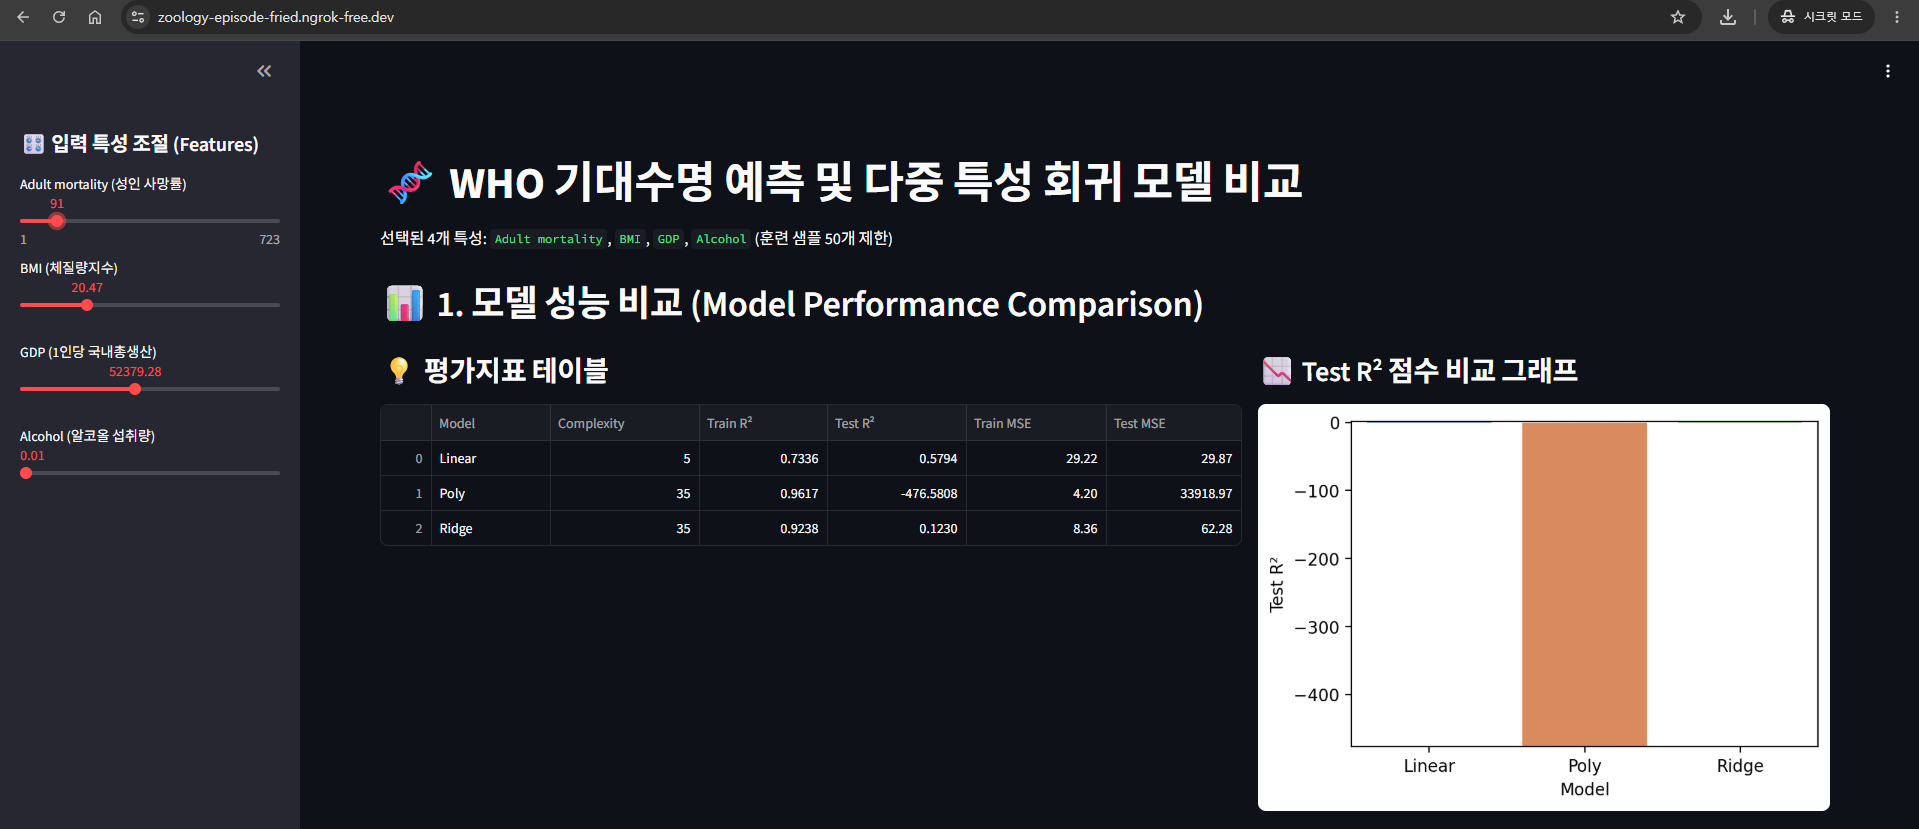

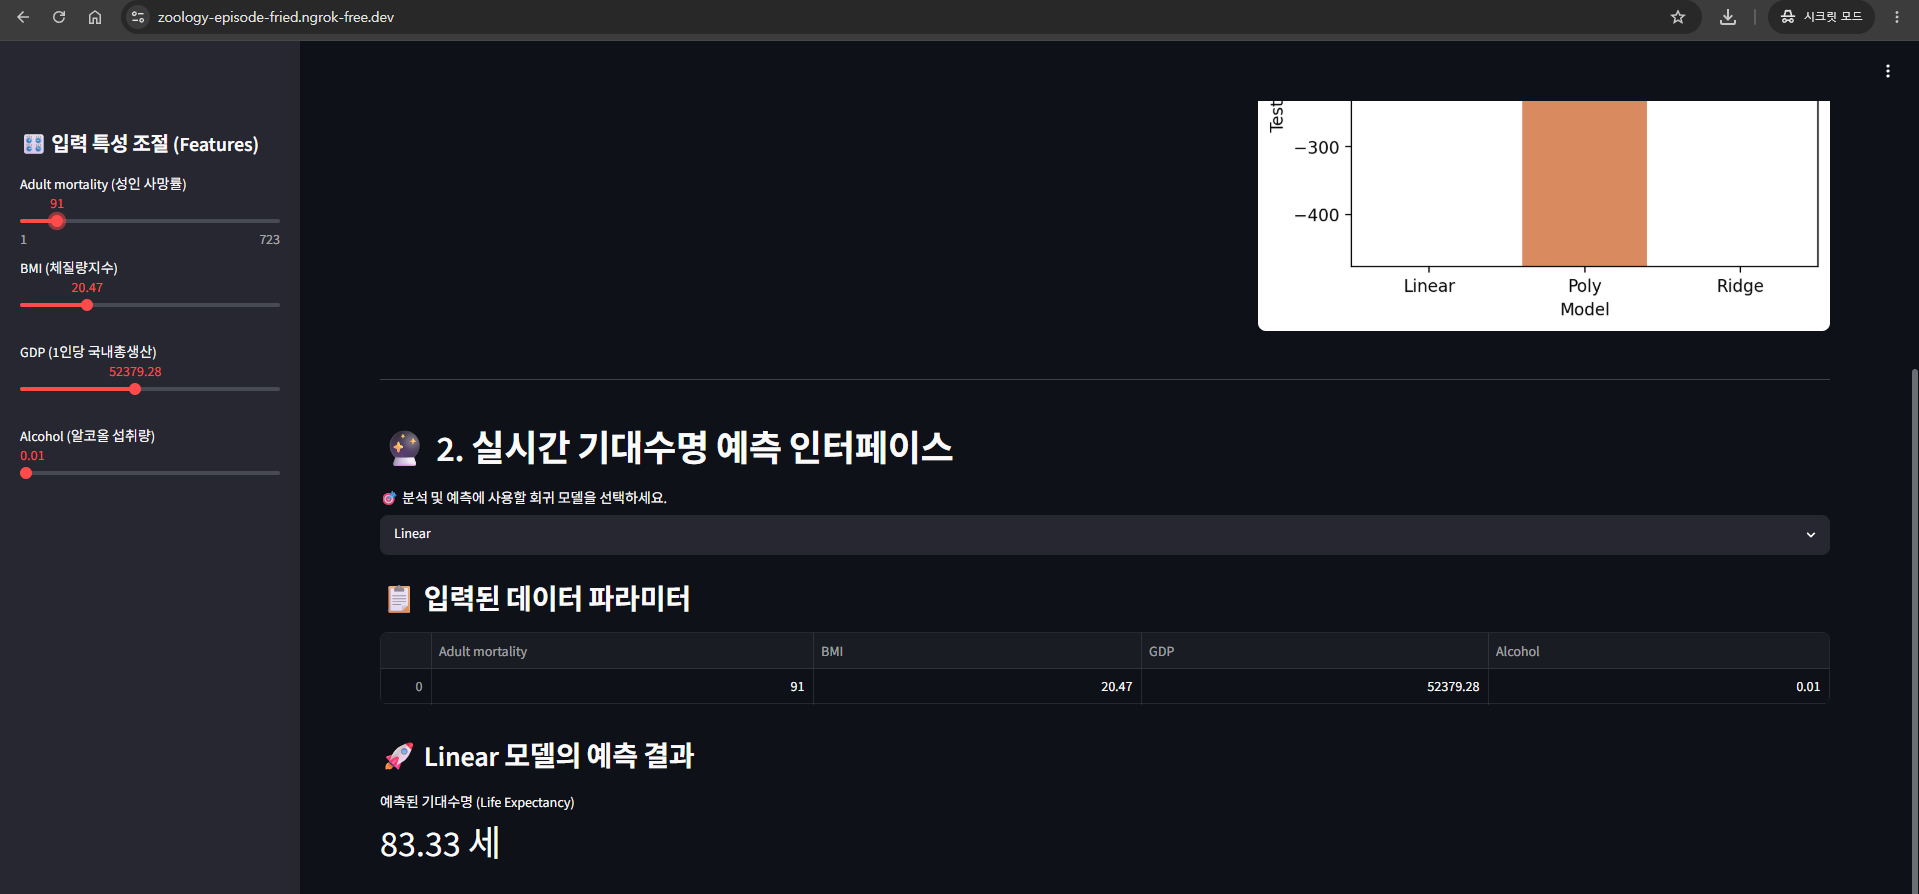